# IMDb Sentiment Classifier: TF-IDF/ CountVectorizer + Logistic Regression
This notebook builds a logistic regression model to classify IMDb movie reviews into positive or negative sentiments using TF-IDF vectorization of cleaned review text in comparison to using CountVectorizer

## Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Load Cleaned Data

In [2]:
# Load the cleaned data that we did in 01_eda_preprocessing.ipynb
imdb_data_df = pd.read_csv('../data/imdb_clean.csv')
imdb_data_df.head()

,clean_review,sentiment
0,one reviewers mentioned watching oz episode ho...,positive
1,wonderful little production filming technique ...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically family little boy jake thinks zombie...,negative
4,petter mattei love time money visually stunnin...,positive


## Encoding Labels & Splitting the Data

In [3]:
# Encoding labels to be 0 & 1 such that 1 represents positive and 0 represents negative
imdb_data_df['label'] = imdb_data_df['sentiment'].map({'positive':1, 'negative':0})
imdb_data_df

,clean_review,sentiment,label
0,one reviewers mentioned watching oz episode ho...,positive,1
1,wonderful little production filming technique ...,positive,1
2,thought wonderful way spend time hot summer we...,positive,1
3,basically family little boy jake thinks zombie...,negative,0
4,petter mattei love time money visually stunnin...,positive,1
...,...,...,...
49995,thought movie right good job creative original...,positive,1
49996,bad plot bad dialogue bad acting idiotic direc...,negative,0
49997,catholic taught parochial elementary schools n...,negative,0
49998,going disagree previous comment side maltin on...,negative,0


In [4]:
# Setting the Features and labels to X and y
X = imdb_data_df['clean_review']
y = imdb_data_df['label']

# Showing an example
print("Feature:", X[0])
print("Label:", y[0])

Feature: one reviewers mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use word called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home many aryans muslims gangstas latinos christians italians irish scuffles death stares dodgy dealings shady agreements never far away would say main appeal show due fact goes shows dare forget pretty pictures painted mainstream audiences forget charm forget romance oz mess around first episode ever saw struck nasty surreal say ready watched developed taste oz got accustomed high levels graphic violence violence injustice crooked guards sold nickel inmates kill order get away well mannered middle class inmates turned prison bitches due lack stre

In [5]:
# Split into train set with 70% and temporary set with 30% to be further split to test and validation sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

#Split temp into validation set with 15% and test set with 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")


Train set size: 35000
Validation set size: 7500
Test set size: 7500


## Feature Extraction Using TF-IDF

In [6]:
# Initializing the TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

# We apply to train data to learn vocabulary & computes TF-IDF values for train set
X_train_tfidf = tfidf.fit_transform(X_train)

# We apply same vocabulary & weights to the test set
X_val_tfidf = tfidf.transform(X_val)

# We apply same vocabulary & weights to the test set
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF validation shape:", X_val_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (35000, 10000)
TF-IDF validation shape: (7500, 10000)
TF-IDF test shape: (7500, 10000)


### Visualize TF-IDF

In [7]:
# Getting the feature names
feature_names = tfidf.get_feature_names_out()

# Getting the average TF-IDF score across all
avg_tfidf_scores = X_train_tfidf.mean(axis=0).A1 

# Creating a dataframe with the term and score
tfidf_df = pd.DataFrame({'term': feature_names, 'score': avg_tfidf_scores})

# Viewing top 30 terms
top_30_terms = tfidf_df.sort_values(by='score', ascending=False).head(30)
top_30_terms


,term,score
5676,movie,0.048887
3081,film,0.041922
6226,one,0.027969
4956,like,0.023651
3713,good,0.020873
7142,really,0.017690
8458,story,0.017617
8980,time,0.017482
9875,would,0.017476
7775,see,0.017178


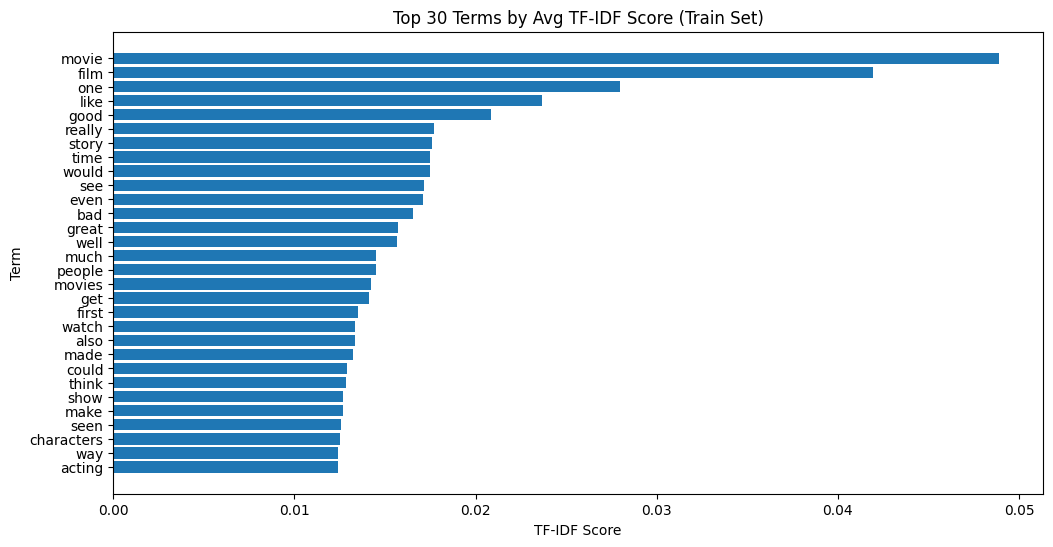

In [8]:
# Plotting top 30 terms
plt.figure(figsize=(12,6))
plt.barh(top_30_terms['term'][::-1], top_30_terms['score'][::-1])
plt.title("Top 30 Terms by Avg TF-IDF Score (Train Set)")
plt.xlabel("TF-IDF Score")
plt.ylabel("Term")
plt.show()

## Logistic Regression Model on TF-IDF Data

### Training the LR Model

In [9]:
# Initializing the Logistic Regression Model
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Training the model on our train set with tf-idf applied
start = time.time()
lr.fit(X_train_tfidf, y_train)
end = time.time()
train_time = end -start

print(f"Training Time: {train_time:.2f} seconds")

# Checking the training accuracy
train_acc = lr.score(X_train_tfidf, y_train)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Training Accuracy Percentage: {train_acc*100:.2f} %")

Training Time: 0.88 seconds
Training Accuracy: 0.9253
Training Accuracy Percentage: 92.53 %


### Validating on Validation set

In [10]:
# Predicting on the val set
y_val_pred = lr.predict(X_val_tfidf)

# Validation accuracy
val_acc = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Accuracy Percentage: {val_acc*100:.2f} %")

Validation Accuracy: 0.8904
Validation Accuracy Percentage: 89.04 %


### Testing on the Test Set

In [11]:
# Predicting on the test set
y_test_pred = lr.predict(X_test_tfidf)

# Test accuracy
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Accuracy Percentage: {test_acc*100:.2f} %")

Test Accuracy: 0.9021
Test Accuracy Percentage: 90.21 %


In [12]:
# Full report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      3750
           1       0.89      0.91      0.90      3750

    accuracy                           0.90      7500
   macro avg       0.90      0.90      0.90      7500
weighted avg       0.90      0.90      0.90      7500


Confusion Matrix:
[[3348  402]
 [ 332 3418]]


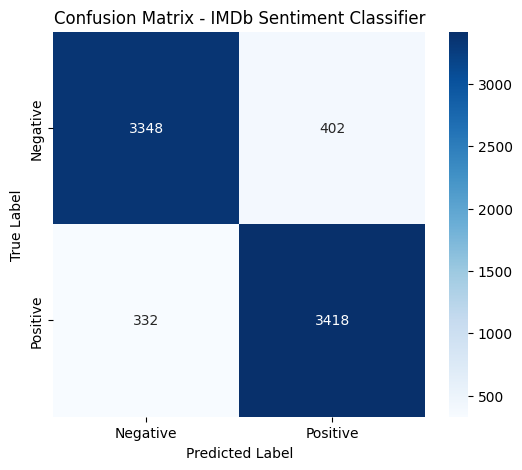

In [13]:
cm = confusion_matrix(y_test, y_test_pred)
labels = ['Negative', 'Positive']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - IMDb Sentiment Classifier')
plt.show()

### Examples

In [14]:
def predict_sentiment(text):
    vectorized = tfidf.transform([text])
    prediction = lr.predict(vectorized)[0]
    return "Positive" if prediction == 1 else "Negative"

print(predict_sentiment("the movie was surprisingly amazing"))
print(predict_sentiment("this was the worst movie ever"))
print(predict_sentiment("i don't like this movie at all"))

Positive
Negative
Negative


## Feature Extraction Using CountVectorizer

In [15]:
# Initialize CountVectorizer
count_vectorizer = CountVectorizer(max_features=10000, ngram_range=(1,2))

# We apply to train data to learn vocabulary & computes CountVectorizer values for train set
X_train_count = count_vectorizer.fit_transform(X_train)

# We apply same vocabulary & weights to the test set
X_val_count = count_vectorizer.transform(X_val)

# We apply same vocabulary & weights to the test set
X_test_count = count_vectorizer.transform(X_test)

print("CountVectorizer train shape:", X_train_count.shape)
print("CountVectorizer validation shape:", X_val_count.shape)
print("CountVectorizer test shape:", X_test_count.shape)

CountVectorizer train shape: (35000, 10000)
CountVectorizer validation shape: (7500, 10000)
CountVectorizer test shape: (7500, 10000)


### Visualize CountVectorizer

In [16]:
# Getting the feature names
feature_names = count_vectorizer.get_feature_names_out()

# Summing frequencies core across all
term_frequencies = X_train_count.sum(axis=0).A1  

# Creating a dataframe with the term and score
count_df = pd.DataFrame({'term': feature_names, 'frequency': term_frequencies})

# Viewing top 30 terms
top_30_count = count_df.sort_values(by='frequency', ascending=False).head(30)
top_30_count


,term,frequency
5676,movie,61540
3081,film,55649
6226,one,37529
4956,like,27881
3713,good,20800
8980,time,17552
2708,even,17355
9875,would,17192
8458,story,16192
7142,really,16162


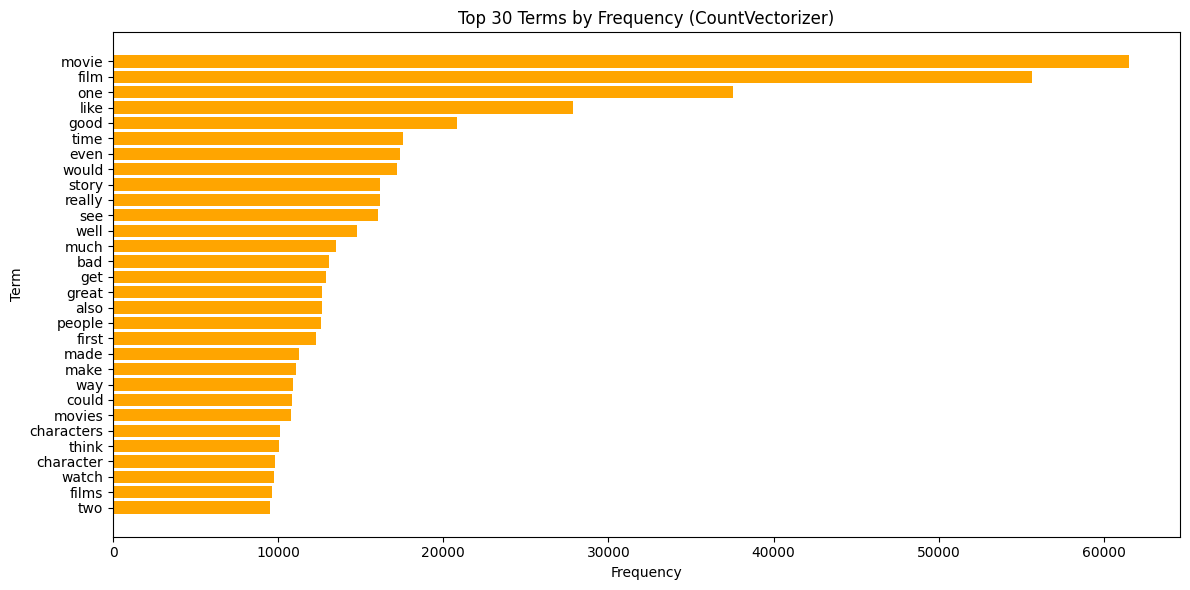

In [17]:
# Plotting
plt.figure(figsize=(12,6))
plt.barh(top_30_count['term'][::-1], top_30_count['frequency'][::-1], color='orange')
plt.title("Top 30 Terms by Frequency (CountVectorizer)")
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

## Logistic Regression Model on CountVectorizer Data

### Training the LR Model

In [18]:
# Initializing the Logistic Regression Model
lr_count = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Training the model on our train set with tf-idf applied
start = time.time()
lr_count.fit(X_train_count, y_train)
end = time.time()
train_time = end - start

print(f"Training Time: {train_time:.2f} seconds")

# Checking the training accuracy
train_acc_count = lr_count.score(X_train_count, y_train)
print(f"Training Accuracy: {train_acc_count:.4f}")
print(f"Training Accuracy Percentage: {train_acc_count*100:.2f} %")

Training Time: 6.32 seconds
Training Accuracy: 0.9855
Training Accuracy Percentage: 98.55 %


### Validating on Val Set

In [19]:
# Predicting on the val set
y_pred_val_count = lr_count.predict(X_val_count)

# Test accuracy
val_acc_count = accuracy_score(y_val, y_pred_val_count)
print(f"Validation Accuracy: {val_acc_count:.4f}")
print(f"Validation Accuracy Percentage: {val_acc_count*100:.2f} %")

Validation Accuracy: 0.8687
Validation Accuracy Percentage: 86.87 %


### Testing on Test Set

In [20]:
# Predicting on the test set
y_pred_count = lr_count.predict(X_test_count)

# Test accuracy
test_acc_count = accuracy_score(y_test, y_pred_count)
print(f"Test Accuracy: {test_acc_count:.4f}")
print(f"Test Accuracy Percentage: {test_acc_count*100:.2f} %")

Test Accuracy: 0.8805
Test Accuracy Percentage: 88.05 %


In [21]:
# Full report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_count))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_count))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      3750
           1       0.88      0.88      0.88      3750

    accuracy                           0.88      7500
   macro avg       0.88      0.88      0.88      7500
weighted avg       0.88      0.88      0.88      7500


Confusion Matrix:
[[3316  434]
 [ 462 3288]]


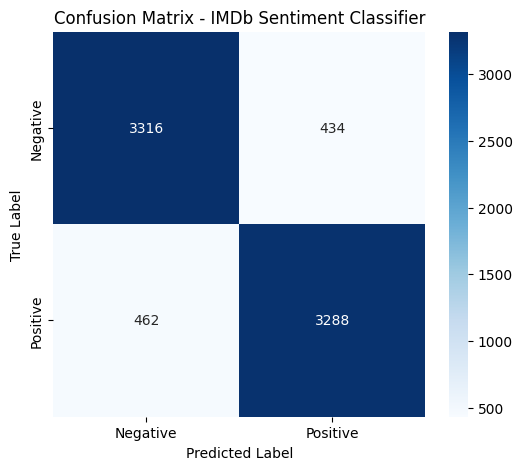

In [22]:
cm = confusion_matrix(y_test, y_pred_count)
labels = ['Negative', 'Positive']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - IMDb Sentiment Classifier')
plt.show()

### Examples

In [23]:
def predict_sentiment_count(text):
    vectorized = count_vectorizer.transform([text])
    prediction = lr_count.predict(vectorized)[0]
    return "Positive" if prediction == 1 else "Negative"

print(predict_sentiment("the movie was surprisingly amazing"))
print(predict_sentiment("this was the worst movie ever"))
print(predict_sentiment("i don't like this movie at all"))

Positive
Negative
Negative


## Comparison 

In [24]:
print("Comparison of Model Performance:\n")
print(f"{'Metric':<20}{'TF-IDF':<15}{'CountVectorizer'}")
print(f"{'Training Accuracy':<20}{train_acc*100:.2f}%{'':<13}{train_acc_count*100:.2f}%")
print(f"{'Validation Accuracy':<20}{val_acc*100:.2f}%{'':<13}{val_acc_count*100:.2f}%")
print(f"{'Test Accuracy':<20}{test_acc*100:.2f}%{'':<13}{test_acc_count*100:.2f}%")

Comparison of Model Performance:

Metric              TF-IDF         CountVectorizer
Training Accuracy   92.53%             98.55%
Validation Accuracy 89.04%             86.87%
Test Accuracy       90.21%             88.05%


## Model Comparison Summary

- CountVectorizer has higher training accuracy, but this is often a sign for overfitting. It memorized patterns from training data too well but failed to generalize as well on unseen data.

- TF-IDF has better test accuracy, meaning it generalizes better. This is expected, as TF-IDF down-weights common terms and focuses on more meaningful, rare ones.

That's why for the next notebook, we chose TF-IDF.